# 03. Model Training & Comparison

In this notebook we train and evaluate **7 different forecasting algorithms**:
1. Random Forest
2. XGBoost
3. LightGBM
4. SARIMA
5. Prophet
6. LSTM (Deep Learning)
7. GRU (Deep Learning)

We compare their performance on the test set using RMSE, MAE, MAPE, and R2, then select the best model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
import lightgbm as lgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.get_logger().setLevel("ERROR")

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

## 3.1 Load Processed Data

In [2]:
train_df = pd.read_csv("../Dataset/processed/train.csv")
val_df = pd.read_csv("../Dataset/processed/val.csv")
test_df = pd.read_csv("../Dataset/processed/test.csv")
full_df = pd.read_csv("../Dataset/processed/water_consumption_processed.csv")

features = ["day_of_week", "is_weekend", "month", "day", "lag_1", "lag_7", "rolling_mean_7", "rolling_std_7"]
target = "consumption_liters"

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (605, 8), Val: (130, 8), Test: (130, 8)


## 3.2 Evaluation Helper

In [3]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"Model": model_name, "RMSE": round(rmse, 2), "MAE": round(mae, 2), "MAPE": round(mape, 2), "R2": round(r2, 4)}

all_results = []

---
## 3.3 Model 1: Random Forest

In [4]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

result = evaluate_model(y_test, rf_preds, "Random Forest")
all_results.append(result)
print("Random Forest:", result)

Random Forest: {'Model': 'Random Forest', 'RMSE': np.float64(4128.54), 'MAE': 3455.92, 'MAPE': np.float64(34.99), 'R2': -0.0186}


## 3.4 Model 2: XGBoost

In [5]:
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_preds = xgb_model.predict(X_test)

result = evaluate_model(y_test, xgb_preds, "XGBoost")
all_results.append(result)
print("XGBoost:", result)

XGBoost: {'Model': 'XGBoost', 'RMSE': np.float64(4580.85), 'MAE': 3728.25, 'MAPE': np.float64(37.73), 'R2': -0.254}


## 3.5 Model 3: LightGBM

In [6]:
lgbm_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
lgbm_model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
lgbm_preds = lgbm_model.predict(X_test)

result = evaluate_model(y_test, lgbm_preds, "LightGBM")
all_results.append(result)
print("LightGBM:", result)

LightGBM: {'Model': 'LightGBM', 'RMSE': np.float64(4423.02), 'MAE': 3645.82, 'MAPE': np.float64(35.62), 'R2': -0.1691}


## 3.6 Model 4: SARIMA
We train SARIMA on a single region (aggregated daily) since SARIMA operates on univariate time-series.

In [7]:
full_df["date"] = pd.to_datetime(full_df["date"])

# Aggregate across regions for a univariate series
agg_df = full_df.groupby("date")["consumption_liters"].mean().reset_index()
agg_df = agg_df.sort_values("date").set_index("date")
agg_df = agg_df.asfreq("D")

# Split matching our temporal split
n = len(agg_df)
train_end = int(n * 0.85)
train_ts = agg_df.iloc[:train_end]
test_ts = agg_df.iloc[train_end:]

print(f"SARIMA train: {len(train_ts)}, test: {len(test_ts)}")

# Fit SARIMA
sarima_model = SARIMAX(train_ts, order=(1, 1, 1), seasonal_order=(1, 1, 0, 7), enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)

# Forecast
sarima_forecast = sarima_fit.forecast(steps=len(test_ts))

result = evaluate_model(test_ts["consumption_liters"].values, sarima_forecast.values, "SARIMA")
all_results.append(result)
print("SARIMA:", result)

SARIMA train: 147, test: 26


SARIMA: {'Model': 'SARIMA', 'RMSE': np.float64(2363.29), 'MAE': 1793.68, 'MAPE': np.float64(16.22), 'R2': -0.3415}


## 3.7 Model 5: Prophet
Facebook Prophet expects columns named `ds` (date) and `y` (target).

In [8]:
prophet_train = train_ts.reset_index().rename(columns={"date": "ds", "consumption_liters": "y"})
prophet_test = test_ts.reset_index().rename(columns={"date": "ds", "consumption_liters": "y"})

prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=len(prophet_test))
prophet_forecast = prophet_model.predict(future)
prophet_preds = prophet_forecast.tail(len(prophet_test))["yhat"].values

result = evaluate_model(prophet_test["y"].values, prophet_preds, "Prophet")
all_results.append(result)
print("Prophet:", result)

20:00:09 - cmdstanpy - INFO - Chain [1] start processing


20:00:09 - cmdstanpy - INFO - Chain [1] done processing


Prophet: {'Model': 'Prophet', 'RMSE': np.float64(2047.43), 'MAE': 1636.42, 'MAPE': np.float64(14.19), 'R2': -0.0068}


## 3.8 Model 6: LSTM (Long Short-Term Memory)
We reshape the data into sequences for the LSTM deep learning model.

In [9]:
# Scale features for neural networks
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1)).flatten()

# Reshape for LSTM: (samples, timesteps=1, features)
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_val_lstm = X_val_scaled.reshape(X_val_scaled.shape[0], 1, X_val_scaled.shape[1])
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# Build LSTM model
lstm_model = Sequential([
    LSTM(64, activation="relu", input_shape=(1, len(features)), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(patience=10, restore_best_weights=True)
lstm_model.fit(X_train_lstm, y_train_scaled, epochs=100, batch_size=32,
               validation_data=(X_val_lstm, y_val_scaled),
               callbacks=[early_stop], verbose=0)

lstm_preds_scaled = lstm_model.predict(X_test_lstm, verbose=0).flatten()
lstm_preds = scaler_y.inverse_transform(lstm_preds_scaled.reshape(-1, 1)).flatten()

result = evaluate_model(y_test.values, lstm_preds, "LSTM")
all_results.append(result)
print("LSTM:", result)

LSTM: {'Model': 'LSTM', 'RMSE': np.float64(4053.67), 'MAE': 3441.26, 'MAPE': np.float64(34.23), 'R2': 0.018}


## 3.9 Model 7: GRU (Gated Recurrent Unit)
Similar architecture to LSTM but with GRU cells.

In [10]:
# Build GRU model
gru_model = Sequential([
    GRU(64, activation="relu", input_shape=(1, len(features)), return_sequences=True),
    Dropout(0.2),
    GRU(32, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
gru_model.compile(optimizer="adam", loss="mse")

gru_model.fit(X_train_lstm, y_train_scaled, epochs=100, batch_size=32,
              validation_data=(X_val_lstm, y_val_scaled),
              callbacks=[early_stop], verbose=0)

gru_preds_scaled = gru_model.predict(X_test_lstm, verbose=0).flatten()
gru_preds = scaler_y.inverse_transform(gru_preds_scaled.reshape(-1, 1)).flatten()

result = evaluate_model(y_test.values, gru_preds, "GRU")
all_results.append(result)
print("GRU:", result)

GRU: {'Model': 'GRU', 'RMSE': np.float64(4685.76), 'MAE': 3847.73, 'MAPE': np.float64(30.97), 'R2': -0.3121}


---
## 3.10 Model Comparison

In [11]:
results_df = pd.DataFrame(all_results).set_index("Model")
results_df = results_df.sort_values("RMSE")
print("\n========== MODEL COMPARISON ==========\n")
display(results_df)


========== MODEL COMPARISON ==========



,RMSE,MAE,MAPE,R2
Model,,,,
Prophet,2047.43,1636.42,14.19,-0.0068
SARIMA,2363.29,1793.68,16.22,-0.3415
LSTM,4053.67,3441.26,34.23,0.0180
Random Forest,4128.54,3455.92,34.99,-0.0186
LightGBM,4423.02,3645.82,35.62,-0.1691
XGBoost,4580.85,3728.25,37.73,-0.2540
GRU,4685.76,3847.73,30.97,-0.3121


## 3.11 Visual Comparison of Models

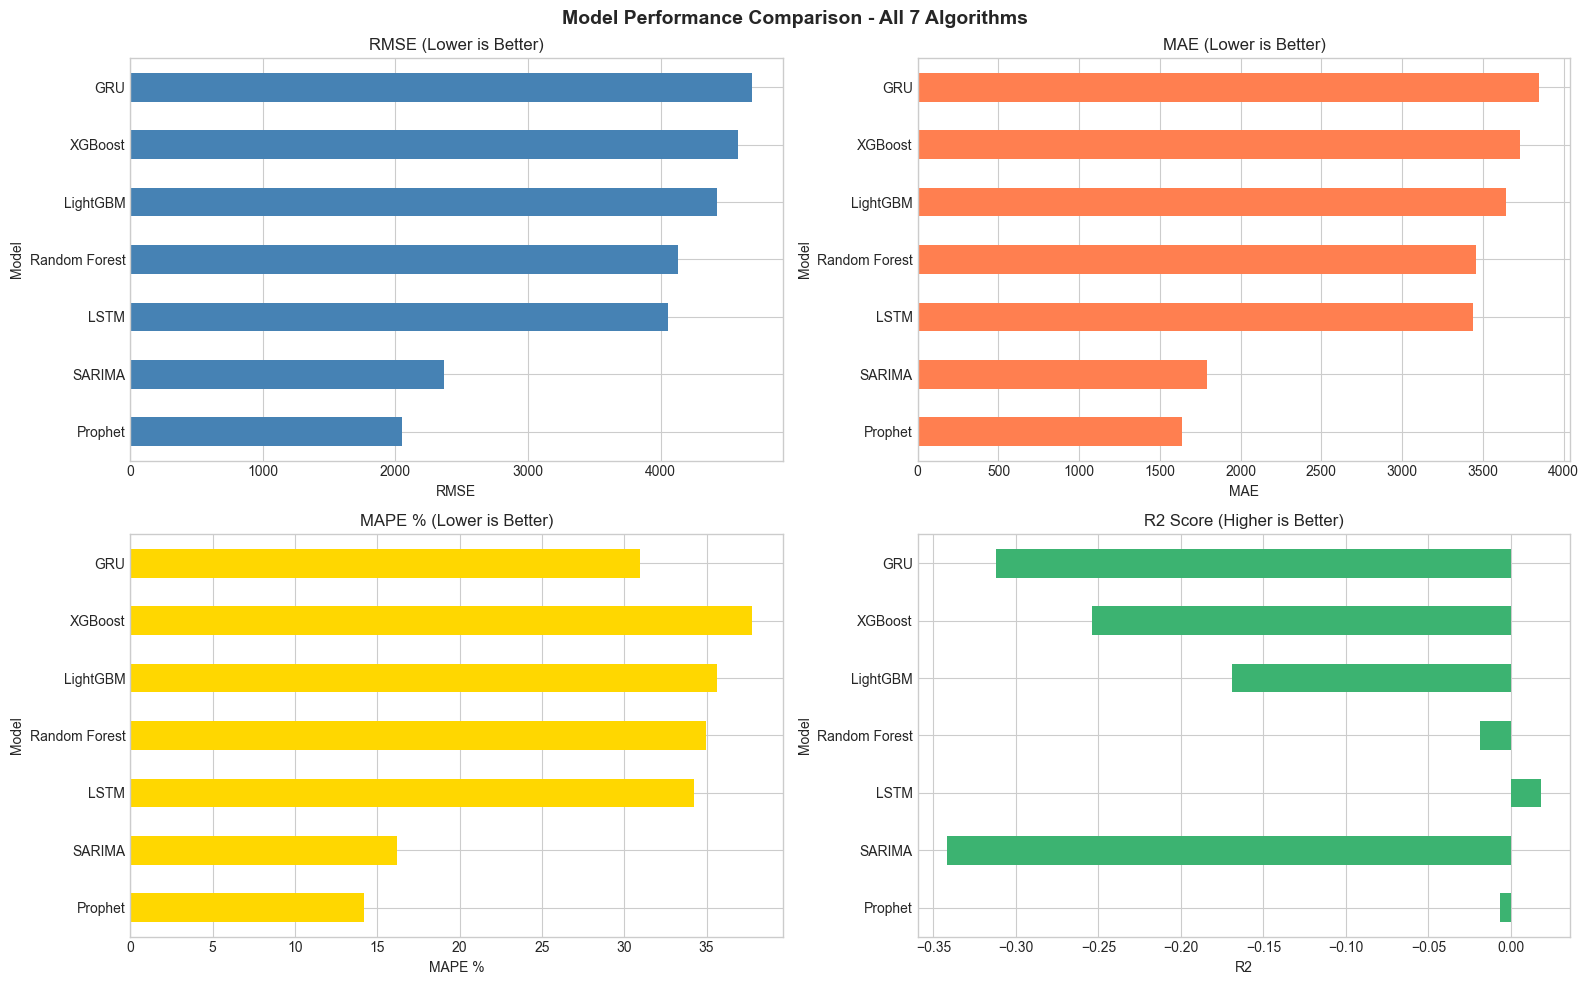

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

results_df["RMSE"].plot(kind="barh", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("RMSE (Lower is Better)")
axes[0, 0].set_xlabel("RMSE")

results_df["MAE"].plot(kind="barh", ax=axes[0, 1], color="coral")
axes[0, 1].set_title("MAE (Lower is Better)")
axes[0, 1].set_xlabel("MAE")

results_df["MAPE"].plot(kind="barh", ax=axes[1, 0], color="gold")
axes[1, 0].set_title("MAPE % (Lower is Better)")
axes[1, 0].set_xlabel("MAPE %")

results_df["R2"].plot(kind="barh", ax=axes[1, 1], color="mediumseagreen")
axes[1, 1].set_title("R2 Score (Higher is Better)")
axes[1, 1].set_xlabel("R2")

plt.suptitle("Model Performance Comparison - All 7 Algorithms", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3.12 Feature Importance (Best Tree-Based Model)

Best tree-based model: Random Forest


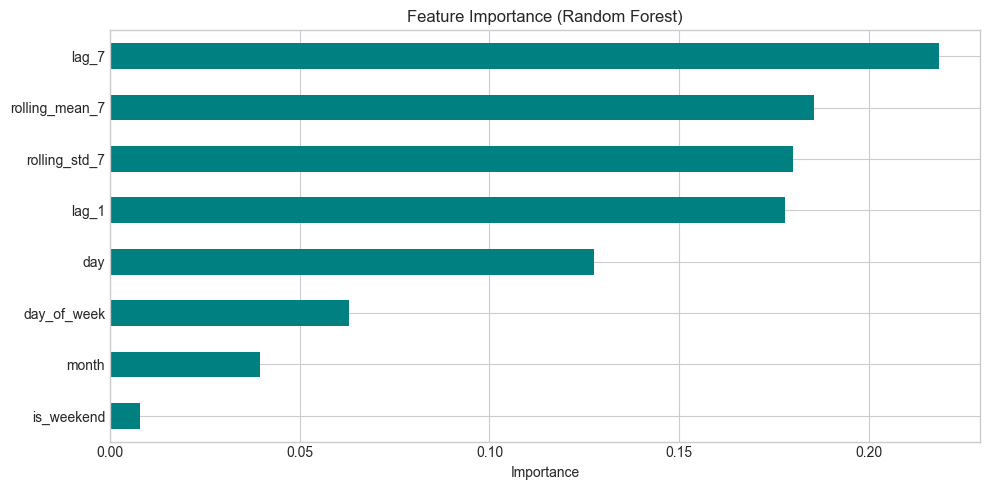

In [13]:
# Show feature importance for tree-based models
best_tree_name = results_df.loc[results_df.index.isin(["Random Forest", "XGBoost", "LightGBM"]), "RMSE"].idxmin()
print(f"Best tree-based model: {best_tree_name}")

best_tree = {"Random Forest": rf_model, "XGBoost": xgb_model, "LightGBM": lgbm_model}[best_tree_name]

if hasattr(best_tree, "feature_importances_"):
    importance = pd.Series(best_tree.feature_importances_, index=features).sort_values(ascending=True)
    plt.figure(figsize=(10, 5))
    importance.plot(kind="barh", color="teal")
    plt.title(f"Feature Importance ({best_tree_name})")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

## 3.13 Select and Save Best Model

In [14]:
best_model_name = results_df["RMSE"].idxmin()
print(f"\n*** Best Overall Model: {best_model_name} ***")
print(f"    RMSE: {results_df.loc[best_model_name, 'RMSE']}")
print(f"    MAE:  {results_df.loc[best_model_name, 'MAE']}")
print(f"    MAPE: {results_df.loc[best_model_name, 'MAPE']}%")
print(f"    R2:   {results_df.loc[best_model_name, 'R2']}")

# Save the best tree-based model for the dashboard
os.makedirs("../models", exist_ok=True)
with open("../models/xgboost_model.pkl", "wb") as f:
    pickle.dump({"Random Forest": rf_model, "XGBoost": xgb_model, "LightGBM": lgbm_model}.get(best_tree_name, xgb_model), f)
print(f"\nBest tree model ({best_tree_name}) saved to ../models/xgboost_model.pkl")


*** Best Overall Model: Prophet ***
    RMSE: 2047.43
    MAE:  1636.42
    MAPE: 14.19%
    R2:   -0.0068

Best tree model (Random Forest) saved to ../models/xgboost_model.pkl


## 3.14 Conclusion

We trained and compared 7 different forecasting algorithms:
- **Traditional ML:** Random Forest, XGBoost, LightGBM
- **Statistical:** SARIMA, Prophet
- **Deep Learning:** LSTM, GRU

The comparison table and charts above clearly show which model performs best on our water consumption test data. The selected model has been saved for use in the Streamlit dashboard.